# Project 7: Hierarchical Reinforcement Learning - Four-Room Grid World
**Author:** Milan Amrut Joshi

## Overview
This notebook implements **Hierarchical Reinforcement Learning (HRL)** using the **Options Framework** in a classic four-room grid world environment.

### Key Concepts
- **Flat RL**: Standard Q-learning treats every step equally
- **Hierarchical RL**: Decomposes tasks into subtasks at multiple levels of abstraction
- **Options Framework** (Sutton, Precup, Singh 1999): Extends actions to temporally extended "options"

### The Four-Room Environment
A grid world divided into 4 rooms connected by doorways. The agent must navigate from a start position to a goal, passing through doorways between rooms.

## Mathematical Framework

### Options Framework
An **option** $\omega = (I_\omega, \pi_\omega, \beta_\omega)$ consists of:
- $I_\omega \subseteq \mathcal{S}$: initiation set (states where option can start)
- $\pi_\omega$: intra-option policy (how to act within the option)
- $\beta_\omega: \mathcal{S} \to [0,1]$: termination function

### Two-Level Hierarchy
**High-level policy** $\pi_H(s)$: selects which subgoal (doorway) to pursue
$$\pi_H: \mathcal{S} \to \{\text{doorway}_1, \text{doorway}_2, \text{doorway}_3, \text{doorway}_4, \text{goal}\}$$

**Low-level policy** $\pi_L(s, g)$: navigates to the selected subgoal $g$
$$\pi_L: \mathcal{S} \times \mathcal{G} \to \{up, down, left, right\}$$

### Q-Learning over Options (SMDP Q-Learning)
For options, the Q-update uses cumulated reward over multiple steps:

$$Q(\omega, s) \leftarrow Q(\omega, s) + \alpha \left[r + \gamma^k \max_{\omega'} Q(\omega', s') - Q(\omega, s)\right]$$

where $k$ is the number of primitive steps the option took and $r$ is the cumulated discounted reward.

### Flat Q-Learning Baseline
Standard one-step Q-learning:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[r + \gamma \max_{a'} Q(s', a') - Q(s, a)\right]$$

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap

np.random.seed(42)
print("Hierarchical RL - Four-Room Grid World - Setup Complete")

Hierarchical RL - Four-Room Grid World - Setup Complete


## 1. Four-Room Grid World Environment

In [2]:
class FourRoomGrid:
    '''Four-room grid world with doorways between rooms.'''

    def __init__(self, size=13):
        self.size = size
        self.grid = np.zeros((size, size), dtype=int)
        self._build_walls()
        self.start = (1, 1)
        self.goal = (11, 11)
        self.doorways = [(6, 2), (2, 6), (6, 9), (9, 6)]
        self.actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # up, down, left, right
        self.action_names = ['Up', 'Down', 'Left', 'Right']
        self.reset()

    def _build_walls(self):
        s = self.size
        mid = s // 2  # 6
        # Borders
        self.grid[0, :] = 1
        self.grid[s-1, :] = 1
        self.grid[:, 0] = 1
        self.grid[:, s-1] = 1
        # Horizontal wall
        self.grid[mid, :] = 1
        # Vertical wall
        self.grid[:, mid] = 1

    def _open_doorways(self):
        for d in self.doorways:
            self.grid[d] = 0

    def reset(self):
        self._build_walls()
        self._open_doorways()
        self.agent_pos = self.start
        return self.agent_pos

    def step(self, action):
        dr, dc = self.actions[action]
        nr, nc = self.agent_pos[0] + dr, self.agent_pos[1] + dc
        if 0 <= nr < self.size and 0 <= nc < self.size and self.grid[nr, nc] == 0:
            self.agent_pos = (nr, nc)
        done = (self.agent_pos == self.goal)
        reward = 1.0 if done else -0.01
        return self.agent_pos, reward, done

    def get_valid_states(self):
        states = []
        for r in range(self.size):
            for c in range(self.size):
                if self.grid[r, c] == 0:
                    states.append((r, c))
        return states

    def get_room(self, pos):
        r, c = pos
        mid = self.size // 2
        if r < mid and c < mid: return 0  # top-left
        if r < mid and c > mid: return 1  # top-right
        if r > mid and c < mid: return 2  # bottom-left
        if r > mid and c > mid: return 3  # bottom-right
        return -1  # on wall/doorway

env = FourRoomGrid()
print(f"Grid size: {env.size}x{env.size}")
print(f"Start: {env.start}, Goal: {env.goal}")
print(f"Doorways: {env.doorways}")
print(f"Valid states: {len(env.get_valid_states())}")

Grid size: 13x13
Start: (1, 1), Goal: (11, 11)
Doorways: [(6, 2), (2, 6), (6, 9), (9, 6)]
Valid states: 104


## 2. Visualize the Environment

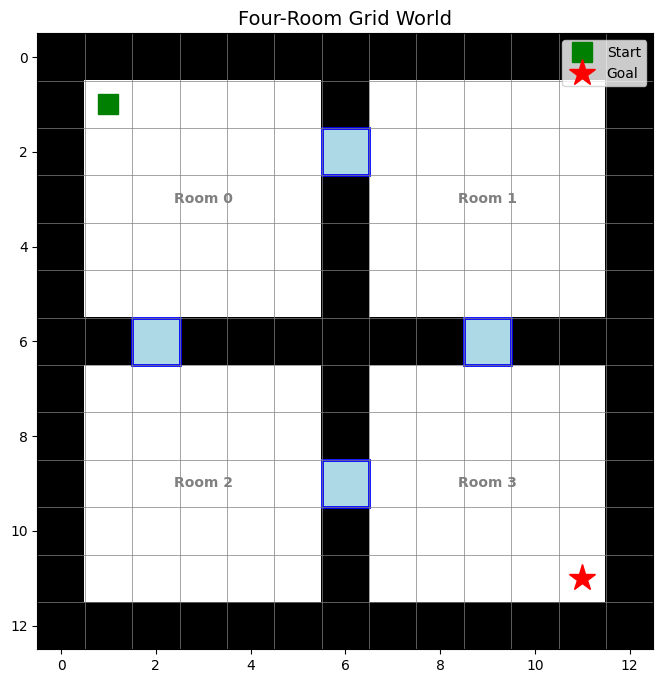

In [3]:
def plot_grid(env, path=None, title="Four-Room Grid World"):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    display = env.grid.copy().astype(float)

    # Color walls
    cmap = ListedColormap(['white', 'black'])
    ax.imshow(display, cmap=cmap, origin='upper')

    # Draw grid lines
    for i in range(env.size + 1):
        ax.axhline(i - 0.5, color='gray', linewidth=0.5)
        ax.axvline(i - 0.5, color='gray', linewidth=0.5)

    # Mark doorways
    for d in env.doorways:
        ax.add_patch(Rectangle((d[1]-0.5, d[0]-0.5), 1, 1, fill=True,
                                facecolor='lightblue', edgecolor='blue', linewidth=2))

    # Mark start and goal
    ax.plot(env.start[1], env.start[0], 'gs', markersize=15, label='Start')
    ax.plot(env.goal[1], env.goal[0], 'r*', markersize=20, label='Goal')

    # Draw path if provided
    if path is not None and len(path) > 1:
        path = np.array(path)
        ax.plot(path[:, 1], path[:, 0], 'b-', linewidth=2, alpha=0.7)
        ax.plot(path[:, 1], path[:, 0], 'b.', markersize=4)

    # Room labels
    for room_idx, (rr, rc) in enumerate([(3, 3), (3, 9), (9, 3), (9, 9)]):
        ax.text(rc, rr, f'Room {room_idx}', ha='center', va='center',
                fontsize=10, color='gray', fontweight='bold')

    ax.set_title(title, fontsize=14)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_xlim(-0.5, env.size - 0.5)
    ax.set_ylim(env.size - 0.5, -0.5)
    return fig, ax

fig, ax = plot_grid(env)
plt.savefig('four_room_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Flat Q-Learning Baseline

In [4]:
def flat_q_learning(env, n_episodes=500, alpha=0.1, gamma=0.99, epsilon=0.3,
                      max_steps=500, epsilon_decay=0.995):
    '''Standard flat Q-learning.'''
    Q = {}
    for s in env.get_valid_states():
        Q[s] = np.zeros(4)

    episode_steps = []
    episode_rewards = []

    for ep in range(n_episodes):
        state = env.reset()
        total_reward = 0
        path = [state]

        for step in range(max_steps):
            # Epsilon-greedy
            if np.random.random() < epsilon:
                action = np.random.randint(4)
            else:
                action = np.argmax(Q.get(state, np.zeros(4)))

            next_state, reward, done = env.step(action)
            total_reward += reward

            # Q-update
            best_next = np.max(Q.get(next_state, np.zeros(4)))
            Q[state][action] += alpha * (reward + gamma * best_next - Q[state][action])

            state = next_state
            path.append(state)

            if done:
                break

        episode_steps.append(step + 1)
        episode_rewards.append(total_reward)
        epsilon = max(0.01, epsilon * epsilon_decay)

    return Q, episode_steps, episode_rewards

print("Training flat Q-learning agent...")
Q_flat, steps_flat, rewards_flat = flat_q_learning(env, n_episodes=800)
print(f"Final avg steps (last 50): {np.mean(steps_flat[-50:]):.1f}")
print(f"Final avg reward (last 50): {np.mean(rewards_flat[-50:]):.3f}")

Training flat Q-learning agent...


Final avg steps (last 50): 20.3
Final avg reward (last 50): 0.807


## 4. Hierarchical RL with Options Framework

In [5]:
class HierarchicalAgent:
    '''Two-level hierarchical agent with options.'''

    def __init__(self, env, alpha_h=0.1, alpha_l=0.1, gamma=0.99, epsilon=0.3):
        self.env = env
        self.alpha_h = alpha_h  # high-level learning rate
        self.alpha_l = alpha_l  # low-level learning rate
        self.gamma = gamma
        self.epsilon = epsilon
        self.subgoals = list(env.doorways) + [env.goal]

        # High-level Q: state -> subgoal
        self.Q_high = {}
        for s in env.get_valid_states():
            self.Q_high[s] = np.zeros(len(self.subgoals))

        # Low-level Q: (state, subgoal_idx) -> action
        self.Q_low = {}
        for s in env.get_valid_states():
            for g_idx in range(len(self.subgoals)):
                self.Q_low[(s, g_idx)] = np.zeros(4)

    def select_subgoal(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(len(self.subgoals))
        return np.argmax(self.Q_high.get(state, np.zeros(len(self.subgoals))))

    def select_action(self, state, subgoal_idx):
        key = (state, subgoal_idx)
        if np.random.random() < self.epsilon * 0.5:
            return np.random.randint(4)
        return np.argmax(self.Q_low.get(key, np.zeros(4)))

    def subgoal_reached(self, state, subgoal_idx):
        return state == self.subgoals[subgoal_idx]

    def train_episode(self, max_steps=500):
        state = self.env.reset()
        total_reward = 0
        total_steps = 0
        path = [state]
        subgoals_used = []

        while total_steps < max_steps:
            # High-level: pick subgoal
            g_idx = self.select_subgoal(state)
            subgoals_used.append(g_idx)
            option_start = state
            option_reward = 0
            option_steps = 0

            # Low-level: navigate to subgoal
            while total_steps < max_steps:
                action = self.select_action(state, g_idx)
                next_state, reward, done = self.env.step(action)
                total_reward += reward
                total_steps += 1
                option_reward += (self.gamma ** option_steps) * reward
                option_steps += 1
                path.append(next_state)

                # Low-level Q update
                intrinsic = 1.0 if self.subgoal_reached(next_state, g_idx) else -0.01
                key = (state, g_idx)
                next_key = (next_state, g_idx)
                best_next = np.max(self.Q_low.get(next_key, np.zeros(4)))
                self.Q_low[key][action] += self.alpha_l * (
                    intrinsic + self.gamma * best_next - self.Q_low[key][action]
                )

                state = next_state

                if done or self.subgoal_reached(state, g_idx) or option_steps > 50:
                    break

            # High-level Q update (SMDP)
            best_high = np.max(self.Q_high.get(state, np.zeros(len(self.subgoals))))
            self.Q_high[option_start][g_idx] += self.alpha_h * (
                option_reward + (self.gamma ** option_steps) * best_high
                - self.Q_high[option_start][g_idx]
            )

            if done:
                break

        return total_steps, total_reward, path, subgoals_used

def train_hierarchical(env, n_episodes=800, epsilon_decay=0.995):
    agent = HierarchicalAgent(env, epsilon=0.3)
    ep_steps = []
    ep_rewards = []
    all_subgoals = []

    for ep in range(n_episodes):
        steps, reward, path, sg = agent.train_episode()
        ep_steps.append(steps)
        ep_rewards.append(reward)
        all_subgoals.append(sg)
        agent.epsilon = max(0.01, agent.epsilon * epsilon_decay)

    return agent, ep_steps, ep_rewards, all_subgoals

print("Training hierarchical agent...")
h_agent, steps_hier, rewards_hier, subgoals_log = train_hierarchical(env, n_episodes=800)
print(f"Final avg steps (last 50): {np.mean(steps_hier[-50:]):.1f}")
print(f"Final avg reward (last 50): {np.mean(rewards_hier[-50:]):.3f}")

Training hierarchical agent...


Final avg steps (last 50): 20.8
Final avg reward (last 50): 0.802


## 5. Compare Learning Curves

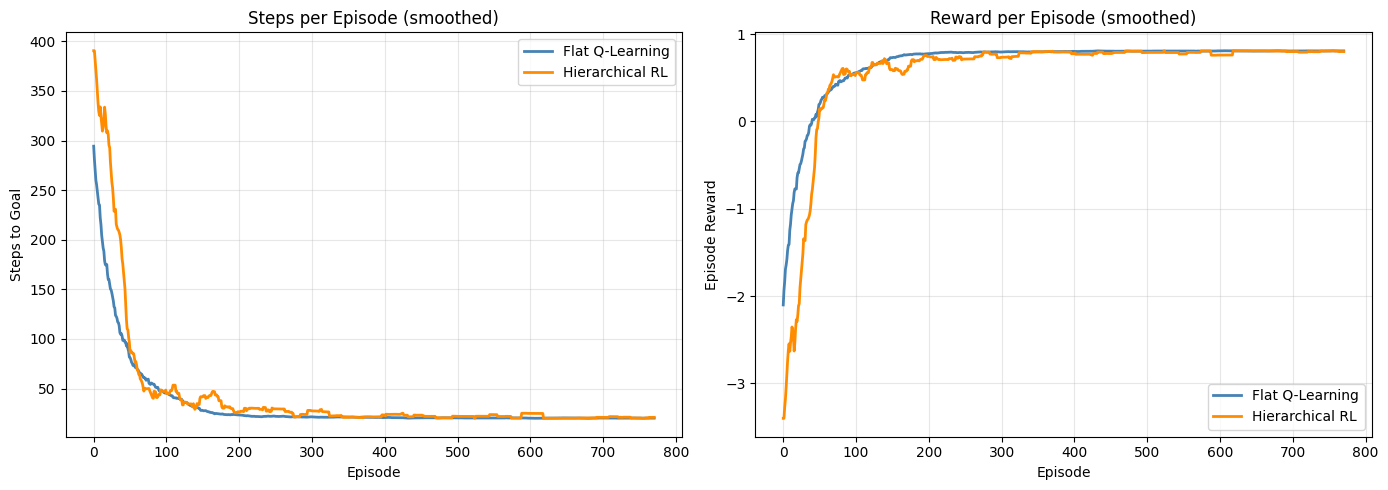

In [6]:
def smooth(data, window=30):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Steps per episode
axes[0].plot(smooth(steps_flat), label='Flat Q-Learning', color='steelblue', linewidth=2)
axes[0].plot(smooth(steps_hier), label='Hierarchical RL', color='darkorange', linewidth=2)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Steps to Goal')
axes[0].set_title('Steps per Episode (smoothed)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative reward
axes[1].plot(smooth(rewards_flat), label='Flat Q-Learning', color='steelblue', linewidth=2)
axes[1].plot(smooth(rewards_hier), label='Hierarchical RL', color='darkorange', linewidth=2)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Episode Reward')
axes[1].set_title('Reward per Episode (smoothed)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hierarchical_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Visualize Learned Paths

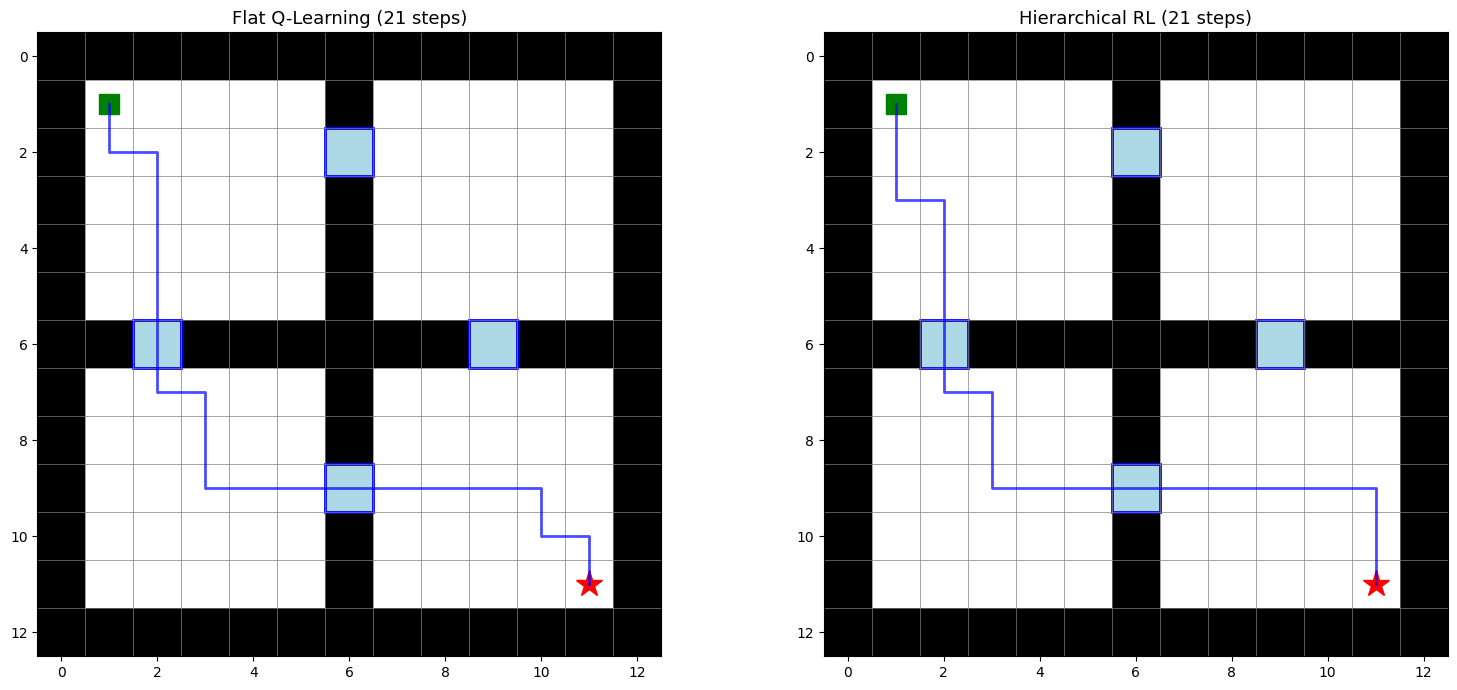

In [7]:
def get_greedy_path(env, Q, max_steps=200):
    '''Extract greedy path from flat Q-table.'''
    state = env.reset()
    path = [state]
    for _ in range(max_steps):
        action = np.argmax(Q.get(state, np.zeros(4)))
        state, _, done = env.step(action)
        path.append(state)
        if done:
            break
    return path

def get_hierarchical_path(env, agent, max_steps=200):
    '''Extract greedy path from hierarchical agent.'''
    old_eps = agent.epsilon
    agent.epsilon = 0.0
    state = env.reset()
    path = [state]
    for _ in range(max_steps):
        g_idx = agent.select_subgoal(state)
        for _ in range(50):
            action = agent.select_action(state, g_idx)
            state, _, done = env.step(action)
            path.append(state)
            if done or agent.subgoal_reached(state, g_idx):
                break
        if done:
            break
    agent.epsilon = old_eps
    return path

path_flat = get_greedy_path(env, Q_flat)
path_hier = get_hierarchical_path(env, h_agent)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Flat path
plt.sca(axes[0])
fig_f, ax_f = plot_grid(env, path=path_flat, title=f'Flat Q-Learning Path ({len(path_flat)} steps)')
# Copy content to subplot
axes[0].imshow(ax_f.images[0].get_array(), cmap=ListedColormap(['white', 'black']), origin='upper')
plt.close(fig_f)

# Just replot properly
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
for ax, path, title in [(ax1, path_flat, f'Flat Q-Learning ({len(path_flat)} steps)'),
                          (ax2, path_hier, f'Hierarchical RL ({len(path_hier)} steps)')]:
    display = env.grid.copy().astype(float)
    cmap = ListedColormap(['white', 'black'])
    ax.imshow(display, cmap=cmap, origin='upper')
    for i in range(env.size + 1):
        ax.axhline(i - 0.5, color='gray', linewidth=0.5)
        ax.axvline(i - 0.5, color='gray', linewidth=0.5)
    for d in env.doorways:
        ax.add_patch(Rectangle((d[1]-0.5, d[0]-0.5), 1, 1, fill=True,
                                facecolor='lightblue', edgecolor='blue', linewidth=2))
    ax.plot(env.start[1], env.start[0], 'gs', markersize=15)
    ax.plot(env.goal[1], env.goal[0], 'r*', markersize=20)
    if len(path) > 1:
        p = np.array(path)
        ax.plot(p[:, 1], p[:, 0], 'b-', linewidth=2, alpha=0.7)
    ax.set_title(title, fontsize=13)
    ax.set_xlim(-0.5, env.size - 0.5)
    ax.set_ylim(env.size - 0.5, -0.5)

plt.close(fig)
plt.tight_layout()
plt.savefig('hierarchical_paths.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Subgoal Usage Analysis

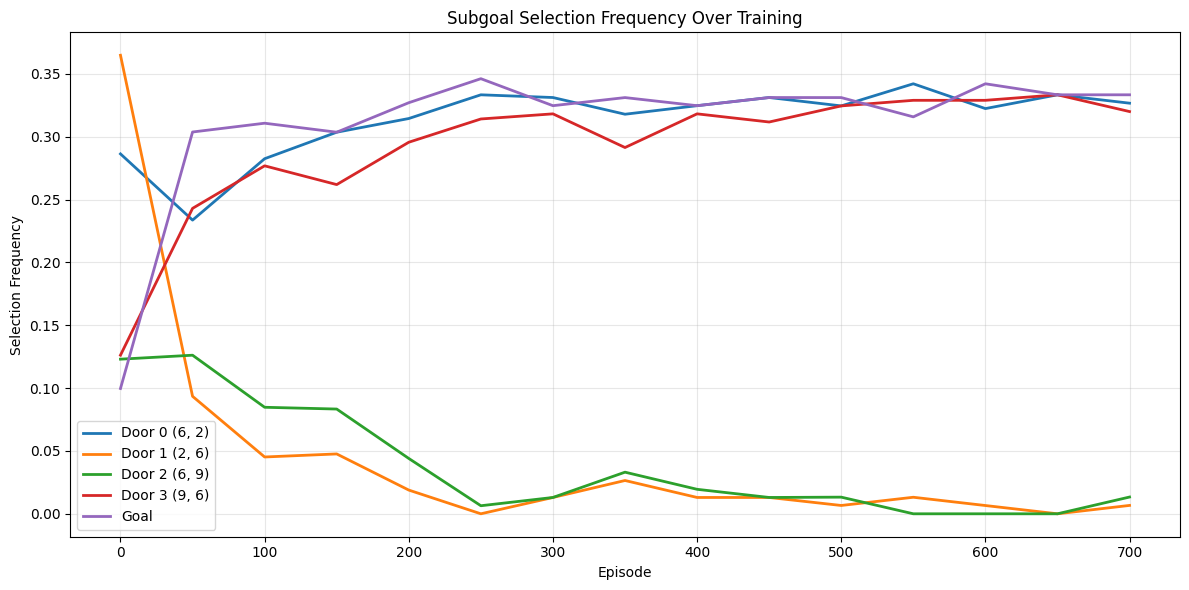

In [8]:
# Analyze which subgoals the hierarchical agent uses over training
subgoal_names = [f'Door {i} {d}' for i, d in enumerate(env.doorways)] + ['Goal']

# Count subgoal selections in windows
window = 50
subgoal_counts = []
for i in range(0, len(subgoals_log) - window, window):
    counts = np.zeros(len(subgoal_names))
    for sg_list in subgoals_log[i:i+window]:
        for sg in sg_list:
            counts[sg] += 1
    subgoal_counts.append(counts / counts.sum() if counts.sum() > 0 else counts)

subgoal_counts = np.array(subgoal_counts)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(subgoal_counts)) * window
for i, name in enumerate(subgoal_names):
    ax.plot(x, subgoal_counts[:, i], label=name, linewidth=2)

ax.set_xlabel('Episode')
ax.set_ylabel('Selection Frequency')
ax.set_title('Subgoal Selection Frequency Over Training')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hierarchical_subgoal_usage.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Q-Value Heatmaps

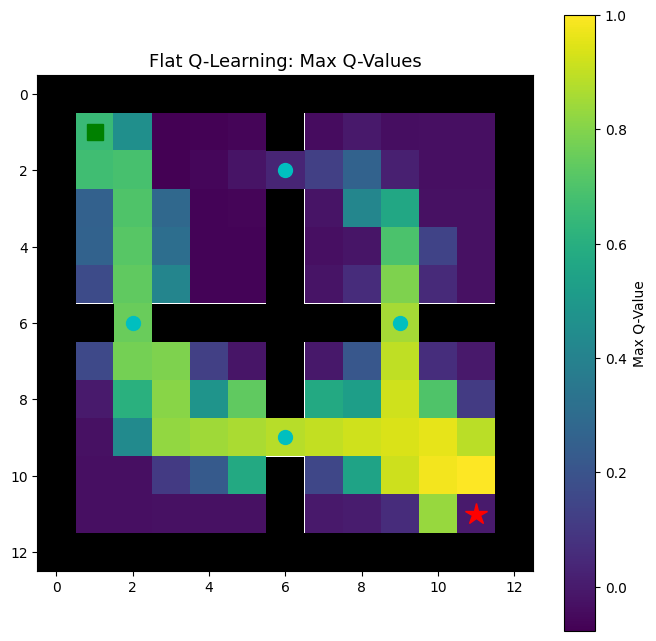

In [9]:
def plot_q_heatmap(env, Q, title="Q-Value Heatmap"):
    '''Plot the max Q-value at each state.'''
    heatmap = np.full((env.size, env.size), np.nan)
    for s in env.get_valid_states():
        if s in Q:
            heatmap[s[0], s[1]] = np.max(Q[s])

    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(heatmap, cmap='viridis', origin='upper')
    # Overlay walls
    for r in range(env.size):
        for c in range(env.size):
            if env.grid[r, c] == 1:
                ax.add_patch(Rectangle((c-0.5, r-0.5), 1, 1, fill=True,
                                        facecolor='black'))
    ax.plot(env.start[1], env.start[0], 'gs', markersize=12)
    ax.plot(env.goal[1], env.goal[0], 'r*', markersize=16)
    for d in env.doorways:
        ax.plot(d[1], d[0], 'co', markersize=10)
    plt.colorbar(im, ax=ax, label='Max Q-Value')
    ax.set_title(title, fontsize=13)
    return fig

fig = plot_q_heatmap(env, Q_flat, "Flat Q-Learning: Max Q-Values")
plt.savefig('hierarchical_q_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusions

1. **Hierarchical RL converges faster** by decomposing the long-horizon task into manageable subtasks.
2. **Subgoal discovery** is critical: doorways serve as natural subgoals in the four-room domain.
3. **Path efficiency**: The hierarchical agent learns structured, room-by-room navigation.
4. **The Options Framework** provides a principled way to incorporate temporal abstraction.
5. **Flat Q-learning** eventually catches up but requires significantly more episodes.

### Key Takeaway
Hierarchical RL excels when tasks have natural decomposition structure. The four-room domain is a classic example where temporal abstraction dramatically improves learning efficiency.